# House Price prediction

#### Import dependencies

In [25]:
#!pip install pandas scikit-learn matplotlib seaborn gradio
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr

#### Load the dataset using pandas	

In [26]:
data = pd.read_csv(r"House_Prices.csv")

#### Print the first few rows to inspect the data	

In [27]:
data.head()

,Location,Size (sqft),Bedrooms,Bathrooms,Year Built,Condition,Price
0,Rural,2465.0,5.0,4,1993,2.0,330453.0
1,Suburban,3704.0,4.0,1,1969,2.0,511827.0
2,Suburban,1251.0,4.0,2,1964,1.0,225852.0
3,Urban,968.0,5.0,4,2000,5.0,400820.0
4,Suburban,3461.0,5.0,3,2009,1.0,475743.0


#### Check for any missing values

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Location     1000 non-null   object 
 1   Size (sqft)  958 non-null    float64
 2   Bedrooms     965 non-null    float64
 3   Bathrooms    1000 non-null   int64  
 4   Year Built   1000 non-null   int64  
 5   Condition    972 non-null    float64
 6   Price        1000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 54.8+ KB


In [29]:
data.isna().sum()

Location        0
Size (sqft)    42
Bedrooms       35
Bathrooms       0
Year Built      0
Condition      28
Price           0
dtype: int64

#### Handle any missing values (e.g., using fillna or dropna)	

In [30]:
numerical_cols = ['Size (sqft)', 'Bedrooms', 'Bathrooms', 'Year Built', 'Condition']
data[numerical_cols] = data[numerical_cols].fillna(data[numerical_cols].median())

In [31]:
categorical_cols = ['Location']
for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

In [32]:
data.isna().sum()

Location       0
Size (sqft)    0
Bedrooms       0
Bathrooms      0
Year Built     0
Condition      0
Price          0
dtype: int64

#### Encode categorical columns

In [33]:
le = LabelEncoder()
data['Location'] = le.fit_transform(data['Location'])

#### Normalize or scale numeric columns

In [34]:
scaler = StandardScaler()
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])

#### Generate summary statistics of the dataset	

In [35]:
data.describe()

,Location,Size (sqft),Bedrooms,Bathrooms,Year Built,Condition,Price
count,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000
mean,1.009000,-1.350031e-16,5.329071e-17,-6.394885e-17,-9.552359e-16,-2.486900e-17,399455.855000
std,0.832834,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,125207.117584
min,0.000000,-1.812525e+00,-1.478544e+00,-1.354096e+00,-1.668863e+00,-1.382603e+00,127783.000000
25%,0.000000,-8.367497e-01,-8.777539e-01,-4.603033e-01,-8.646603e-01,-6.621218e-01,306762.250000
50%,1.000000,-2.810722e-02,-2.769641e-01,4.334895e-01,-1.315109e-02,5.835894e-02,388812.000000
75%,2.000000,8.395888e-01,9.246155e-01,1.327282e+00,8.856642e-01,7.788397e-01,482083.500000
max,2.000000,1.750739e+00,1.525405e+00,1.327282e+00,1.784479e+00,1.499320e+00,798554.000000


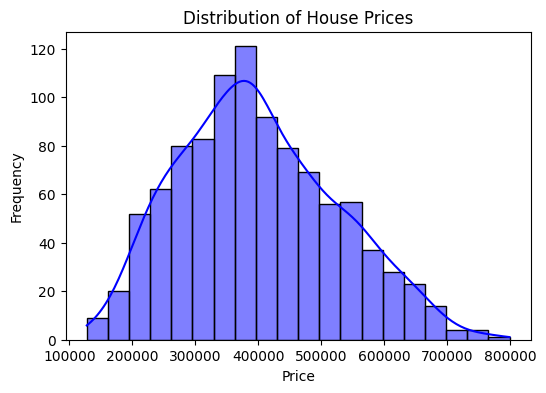

In [36]:
plt.figure(figsize=(6, 4))
sns.histplot(data["Price"], kde=True, color="blue")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

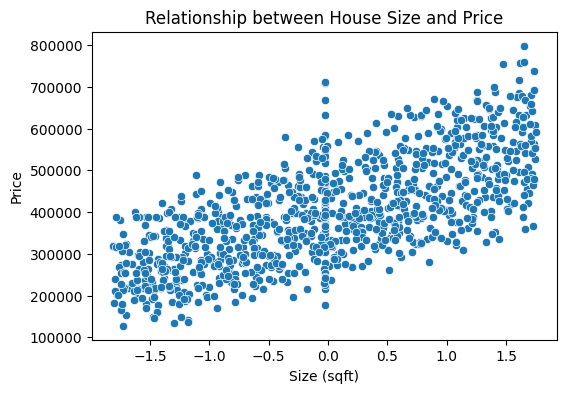

In [37]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=data['Size (sqft)'], y=data['Price'])
plt.title("Relationship between House Size and Price")
plt.xlabel("Size (sqft)")
plt.ylabel("Price")
plt.show()

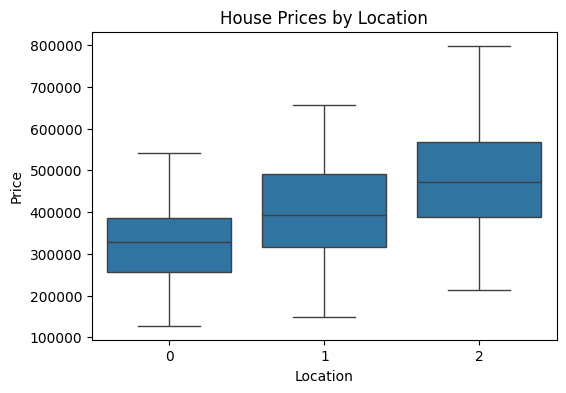

In [38]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=data , x = "Location" , y = "Price")
plt.title("House Prices by Location")
plt.xlabel("Location")
plt.ylabel("Price")
plt.show()

#### Separate features (X) and labels (y).

In [39]:
x = data.drop('Price', axis=1)
y = data['Price']

#### Use train_test_split from sklearn to split the data into 80% training and 20% testing	

In [40]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#### Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(x_train , y_train)
lr_y_pred = lr.predict(x_test)
print("MSE = ",mean_squared_error(y_test , lr_y_pred))
print("MAE = ",mean_absolute_error(y_test , lr_y_pred))
print("R2_score = ",r2_score(y_test , lr_y_pred))

MSE =  1463322279.2036383
MAE =  26691.58559942496
R2_score =  0.9154778685513982


#### Random Forest Regressor

In [ ]:
rf = RandomForestRegressor()
rf.fit(x_train , y_train)
rf_y_pred = rf.predict(x_test)
print("MSE = ",mean_squared_error(y_test , rf_y_pred))
print("MAE = ",mean_absolute_error(y_test , rf_y_pred))
print("R2_score = ",r2_score(y_test , rf_y_pred))

MSE =  1914598317.0510974
MAE =  30370.54065
R2_score =  0.8894119682827951


#### Decision Tree Regressor

In [ ]:
dt = DecisionTreeRegressor()
dt.fit(x_train,y_train)
dt_y_pred = dt.predict(x_test)
print("MSE = ",mean_squared_error(y_test , dt_y_pred))
print("MAE = ",mean_absolute_error(y_test , dt_y_pred))
print("r2_score = ",r2_score(y_test , dt_y_pred))

MSE =  4207491942.12
MAE =  45505.04
r2_score =  0.7569734350013885


#### Plot predicted vs. actual values using a scatter plot.	

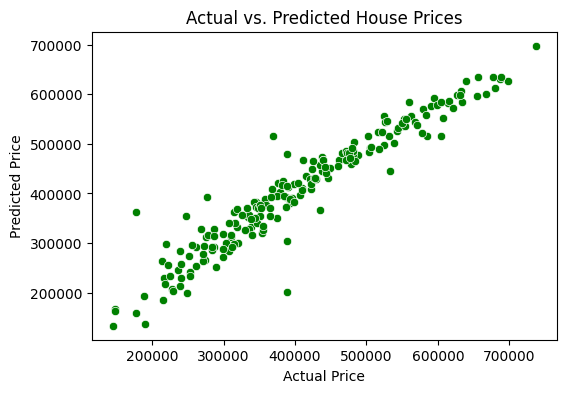

In [44]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x = y_test , y = lr_y_pred , color = 'green')
plt.title("Actual vs. Predicted House Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

#### Use GridSearchCV or RandomizedSearchCV to find optimal parameters for models.	

In [45]:
from sklearn.model_selection import GridSearchCV
grid_params = {
    "max_depth": [x for x in range(10, 20)],
    "max_leaf_nodes": [x for x in range(40, 50)]  
}
grid_model = GridSearchCV(DecisionTreeRegressor(), grid_params, cv=5)
grid_model.fit(x_train, y_train)
print(grid_model.best_params_)
print(grid_model.best_score_)

{'max_depth': 11, 'max_leaf_nodes': 48}
0.7452051567825798


In [46]:
def predict(Location, Size, Bedrooms, Bathrooms, Year_Built, Condition):
    try:
        input_data = pd.DataFrame({
            "Location": [Location],
            "Size (sqft)": [Size],
            "Bedrooms": [Bedrooms],
            "Bathrooms": [Bathrooms],
            "Year Built": [Year_Built],
            "Condition": [Condition]
        })
        input_data["Location"] = le.transform(input_data["Location"])
        input_data[numerical_cols] = scaler.transform(input_data[numerical_cols])
        prediction = rf.predict(input_data)[0]
        return f"Predicted House Price: ${prediction:}"
    except Exception as e:
        return f"Error: {e}"


In [ ]:
gr.Interface(
    fn = predict,
    inputs = [
        gr.Dropdown(label = "Location" , choices  = ["Rural" , "Suburban" , "Urban"]),
        gr.Number(label = "Size (sqft)"),
        gr.Number(label = "Bedrooms"),
        gr.Number(label = "Bathrooms"),
        gr.Number(label = "Year Built"),
        gr.Number(label = "Condition")
    ],
    outputs = "text",
    title = "House Price Prediction System"
).launch()

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.
